In [1]:
import numpy as np
import matplotlib.pyplot as plt
import acfhod.ClusteringAnalysis.CA as CA
import acfhod.ClusteringAnalysis.CA_parallel as CAp
import acfhod.Plots.Plots as Plots
import plot_setup

plot_setup.set_plt_param(False)

('k',
 None,
 'k',
 'r',
 'm',
 'orange',
 '')

In [2]:
z_array = [1.30, 1.50, 1.70, 1.90, 2.10]
N_z_nrm = np.ones(len(z_array))
M_min, M_sat = 10**12.76, 10**15.15
sigma_logM, alpha = 0.2, 1.0
theta = np.logspace(-0.5, 3.5, 12)/206265

In [3]:
%%time
o1, o2 = CAp.omega_1_and_2halo(theta, M_min, sigma_logM, M_sat, alpha, N_z_nrm, z_array)

Calculating HMF table at redshift 0.00


/Users/giofer/anaconda3/envs/HOD/lib/python3.11/site-packages/hmf/density_field/halofit.py:107: UserWarning: sigma_8 is not used any more, and will be removed in v4
  warnings.warn("sigma_8 is not used any more, and will be removed in v4")


Calculating HMF table at redshift 1.30
Calculating HMF table at redshift 1.70Calculating HMF table at redshift 1.50

Calculating HMF table at redshift 1.90
Calculating HMF table at redshift 2.10


/Users/giofer/anaconda3/envs/HOD/lib/python3.11/site-packages/hmf/density_field/halofit.py:107: UserWarning: sigma_8 is not used any more, and will be removed in v4
  warnings.warn("sigma_8 is not used any more, and will be removed in v4")
/Users/giofer/anaconda3/envs/HOD/lib/python3.11/site-packages/hmf/density_field/halofit.py:107: UserWarning: sigma_8 is not used any more, and will be removed in v4
  warnings.warn("sigma_8 is not used any more, and will be removed in v4")
/Users/giofer/anaconda3/envs/HOD/lib/python3.11/site-packages/hmf/density_field/halofit.py:107: UserWarning: sigma_8 is not used any more, and will be removed in v4
  warnings.warn("sigma_8 is not used any more, and will be removed in v4")
/Users/giofer/anaconda3/envs/HOD/lib/python3.11/site-packages/hmf/density_field/halofit.py:107: UserWarning: sigma_8 is not used any more, and will be removed in v4
  warnings.warn("sigma_8 is not used any more, and will be removed in v4")
/Users/giofer/anaconda3/envs/HOD/lib/pyt

CPU times: user 3.47 s, sys: 439 ms, total: 3.91 s
Wall time: 12.8 s


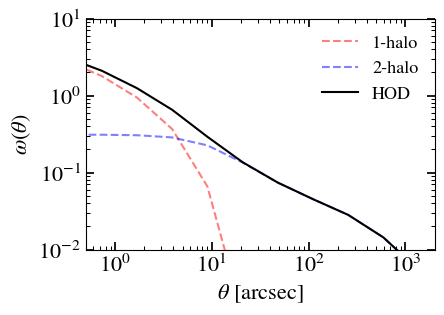

In [4]:
Plots.plot_ACF(theta, o1, o2)

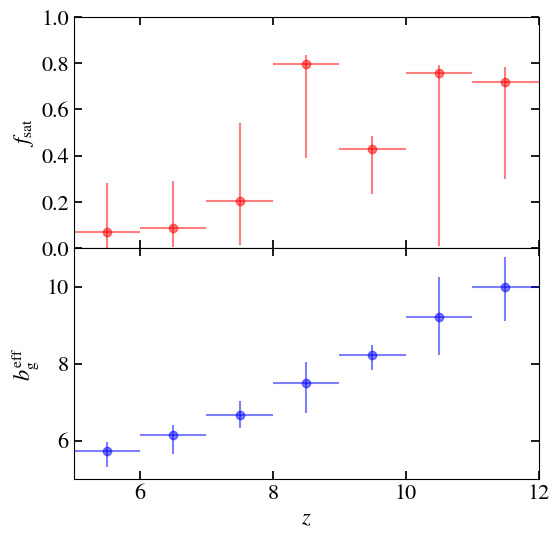

In [ ]:
vals = []
vals.append(np.array([5.5,  5.72, +0.25, -0.41, -1.148, +0.600, -1.536]))
vals.append(np.array([6.5,  6.15, +0.26, -0.51, -1.063, +0.523, -1.127]))
vals.append(np.array([7.5,  6.67, +0.37, -0.35, -0.693, +0.426, -1.262]))
vals.append(np.array([8.5,  7.49, +0.54, -0.77, -0.099, +0.022, -0.308]))
vals.append(np.array([9.5,  8.23, +0.24, -0.39, -0.366, +0.051, -0.262]))
vals.append(np.array([10.5, 9.20, +1.05, -0.98, -0.120, +0.019, -1.950]))
vals.append(np.array([11.5, 9.99, +0.78, -0.89, -0.144, +0.037, -0.382]))
vals = np.array(vals).transpose()

z_array  = vals[0]
eff_bias, eb_err = vals[1], np.array([np.abs(vals[3]), np.abs(vals[2])])
frac_sat, fs_err = np.power(10, vals[4]), np.array([vals[4] + vals[5], vals[4] + vals[6]])
a = np.power(10, fs_err[0]) - frac_sat
b = frac_sat - np.power(10, fs_err[1])
fs_err = np.array([b, a])

Plots.plot_fsat_and_bias(frac_sat, eff_bias, z_array, fs_err=fs_err, eb_err=eb_err,
                   LOG=0, filename='fsat_beff_vs_z.png')